# FIFA World Cup 2026 — Supervised Modeling
## Notebook 04: Match Result Prediction (3-class)

**Target:** match result — 0 = away win, 1 = draw, 2 = home win

**Feature domains:**
- Elo (4 cols): elo_pre_home, elo_pre_away, elo_diff, win_prob_home
- Form home (33 cols): form_5/10/20_* per home team
- Form away (33 cols): form_5/10/20_* per away team
- H2H (11 cols): direct edge, transitive, reliability flags
- Cluster (2 cols): home_cluster, away_cluster (from notebook 03)

**Split strategy:** temporal — train ≤ 2021, val 2022–2023, test 2024–present

In [3]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path("../..").resolve()))

import pandas as pd
import numpy as np
from world_cup_2026.config import PROCESSED_DATA_DIR, FIGURES_DIR, RANDOM_SEED

np.random.seed(RANDOM_SEED)

# ── Load master feature matrix ─────────────────────────────────────────────────
df = pd.read_parquet(PROCESSED_DATA_DIR / "master_features.parquet")
print(f"Master features: {df.shape}")
print(f"Date range: {df['date'].min().date()} → {df['date'].max().date()}")
print(f"Target distribution:\n{df['target'].value_counts().sort_index().to_string()}")

# ── Load cluster labels ────────────────────────────────────────────────────────
df_clusters = pd.read_parquet(PROCESSED_DATA_DIR / "team_snapshot_clustered.parquet")
cluster_map = df_clusters.set_index("team")["cluster_name"].to_dict()

print(f"\nCluster map loaded: {len(cluster_map)} teams")

# ── Join cluster labels ────────────────────────────────────────────────────────
df["home_cluster"] = df["home_team"].map(cluster_map)
df["away_cluster"] = df["away_team"].map(cluster_map)

missing_home = df["home_cluster"].isna().sum()
missing_away = df["away_cluster"].isna().sum()
print(f"Missing home_cluster: {missing_home}")
print(f"Missing away_cluster: {missing_away}")

# ── Temporal split ─────────────────────────────────────────────────────────────
df["year"] = df["date"].dt.year

train = df[df["year"] <= 2021].copy()
val   = df[(df["year"] >= 2022) & (df["year"] <= 2023)].copy()
test  = df[df["year"] >= 2024].copy()

print(f"\nSplit sizes:")
print(f"  Train : {len(train):,} rows ({train['year'].min()}–{train['year'].max()})")
print(f"  Val   : {len(val):,} rows ({val['year'].min()}–{val['year'].max()})")
print(f"  Test  : {len(test):,} rows ({test['year'].min()}–{test['year'].max()})")
print(f"\nTarget distribution — Train:")
print((train["target"].value_counts(normalize=True).sort_index() * 100).round(1).to_string())

2026-04-04 23:56:17.467 | INFO     | world_cup_2026.config:<module>:12 - PROJ_ROOT path is: C:\Users\feder\Documents\data_repos\world-cup-2026-predictor


Master features: (9796, 97)
Date range: 2016-01-03 → 2026-03-31
Target distribution:
target
0    2845
1    2285
2    4666

Cluster map loaded: 48 teams
Missing home_cluster: 6679
Missing away_cluster: 7183

Split sizes:
  Train : 5,382 rows (2016–2021)
  Val   : 2,023 rows (2022–2023)
  Test  : 2,391 rows (2024–2026)

Target distribution — Train:
target
0    28.7
1    23.6
2    47.8


In [4]:
from sklearn.preprocessing import StandardScaler, LabelEncoder

# ── Fill missing cluster labels ────────────────────────────────────────────────
df["home_cluster"] = df["home_cluster"].fillna("Non-WC2026")
df["away_cluster"] = df["away_cluster"].fillna("Non-WC2026")

# Rebuild splits after fillna
train = df[df["year"] <= 2021].copy()
val   = df[(df["year"] >= 2022) & (df["year"] <= 2023)].copy()
test  = df[df["year"] >= 2024].copy()

# ── Define feature groups ──────────────────────────────────────────────────────
ELO_FEATURES = ["elo_pre_home", "elo_pre_away", "elo_diff", "win_prob_home"]

FORM_FEATURES = (
    [c for c in df.columns if c.startswith("home_form_")]
    + [c for c in df.columns if c.startswith("away_form_")]
)

H2H_FEATURES = [
    "h2h_matches", "h2h_win_rate_a", "h2h_goal_diff_a",
    "h2h_elo_edge_a", "h2h_weighted_edge_a", "h2h_decay_weight",
    "h2h_reliable", "transitive_common_rivals", "transitive_edge_a",
    "transitive_goal_diff_edge", "transitive_reliable",
]

CLUSTER_FEATURES_MODEL = ["home_cluster", "away_cluster"]

NEUTRAL_FEATURES = ["neutral"]
RANKING_FEATURES = ["ranking_home", "ranking_away", "ranking_diff"]
SQUAD_VALUE_FEATURES = ["squad_value_home", "squad_value_away", "squad_value_diff"]
NUMERIC_FEATURES = ELO_FEATURES + NEUTRAL_FEATURES + RANKING_FEATURES + SQUAD_VALUE_FEATURES + FORM_FEATURES + H2H_FEATURES
ALL_FEATURES = NUMERIC_FEATURES + CLUSTER_FEATURES_MODEL
TARGET = "target"

print(f"Feature counts:")
print(f"  Elo     : {len(ELO_FEATURES)}")
print(f"  Form    : {len(FORM_FEATURES)}")
print(f"  H2H     : {len(H2H_FEATURES)}")
print(f"  Cluster : {len(CLUSTER_FEATURES_MODEL)}")
print(f"  Total   : {len(ALL_FEATURES)}")

# ── Encode cluster labels ──────────────────────────────────────────────────────
le_home = LabelEncoder()
le_away = LabelEncoder()

# Fit on full dataset to capture all categories
le_home.fit(df["home_cluster"])
le_away.fit(df["away_cluster"])

for split in [train, val, test]:
    split["home_cluster_enc"] = le_home.transform(split["home_cluster"])
    split["away_cluster_enc"] = le_away.transform(split["away_cluster"])

CLUSTER_FEATURES_ENC = ["home_cluster_enc", "away_cluster_enc"]
MODEL_FEATURES = NUMERIC_FEATURES + CLUSTER_FEATURES_ENC

print(f"\nCluster categories: {list(le_home.classes_)}")

# ── Check NaN in features ──────────────────────────────────────────────────────
nan_counts = train[MODEL_FEATURES].isna().sum()
nan_cols = nan_counts[nan_counts > 0]
if len(nan_cols) == 0:
    print("\nNo NaN in train features.")
else:
    print(f"\nNaN found in train:")
    print(nan_cols.to_string())

# ── Build X/y arrays ──────────────────────────────────────────────────────────
X_train = train[MODEL_FEATURES].astype(float).values
y_train = train[TARGET].values
X_val   = val[MODEL_FEATURES].astype(float).values
y_val   = val[TARGET].values
X_test  = test[MODEL_FEATURES].astype(float).values
y_test  = test[TARGET].values

print(f"X_train dtype: {X_train.dtype}")
print(f"X_train shape: {X_train.shape}")

Feature counts:
  Elo     : 4
  Form    : 66
  H2H     : 11
  Cluster : 2
  Total   : 90

Cluster categories: ['Consolidated Mid-Tier', 'Dynamic Mid-Tier', 'Elite', 'Non-WC2026', 'Underdogs']

No NaN in train features.
X_train dtype: float64
X_train shape: (5382, 90)


## 2. Baseline Model — Logistic Regression

Minimal feature set: elo_diff + win_prob_home only.
Purpose: establish a performance floor before adding complexity.

In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, log_loss, classification_report

# ── Baseline uses only Elo features ───────────────────────────────────────────
BASELINE_FEATURES = ["elo_diff", "win_prob_home"]

X_train_bl = train[BASELINE_FEATURES].values
X_val_bl   = val[BASELINE_FEATURES].values
X_test_bl  = test[BASELINE_FEATURES].values

scaler_bl = StandardScaler()
X_train_bl = scaler_bl.fit_transform(X_train_bl)
X_val_bl   = scaler_bl.transform(X_val_bl)
X_test_bl  = scaler_bl.transform(X_test_bl)

# ── Fit ───────────────────────────────────────────────────────────────────────
lr = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=RANDOM_SEED,
)
lr.fit(X_train_bl, y_train)

# ── Evaluate ──────────────────────────────────────────────────────────────────
def evaluate(model, X, y, split_name, use_proba=True):
    y_pred = model.predict(X)
    y_prob = model.predict_proba(X) if use_proba else None
    acc  = accuracy_score(y, y_pred)
    f1   = f1_score(y, y_pred, average="macro")
    ll   = log_loss(y, y_prob) if y_prob is not None else float("nan")
    print(f"\n{split_name}")
    print(f"  Accuracy : {acc:.4f}")
    print(f"  F1-macro : {f1:.4f}")
    print(f"  Log-loss : {ll:.4f}")
    return {"accuracy": acc, "f1_macro": f1, "log_loss": ll}

results = {}
results["baseline_train"] = evaluate(lr, X_train_bl, y_train, "Baseline — Train")
results["baseline_val"]   = evaluate(lr, X_val_bl,   y_val,   "Baseline — Val")
results["baseline_test"]  = evaluate(lr, X_test_bl,  y_test,  "Baseline — Test")

print("\nClassification report — Val:")
print(classification_report(y_val, lr.predict(X_val_bl),
      target_names=["Away Win", "Draw", "Home Win"]))


Baseline — Train
  Accuracy : 0.4043
  F1-macro : 0.3260
  Log-loss : 1.0958

Baseline — Val
  Accuracy : 0.4113
  F1-macro : 0.3262
  Log-loss : 1.0948

Baseline — Test
  Accuracy : 0.3814
  F1-macro : 0.2997
  Log-loss : 1.0995

Classification report — Val:
              precision    recall  f1-score   support

    Away Win       0.33      0.50      0.40       604
        Draw       0.22      0.04      0.07       445
    Home Win       0.50      0.52      0.51       974

    accuracy                           0.41      2023
   macro avg       0.35      0.36      0.33      2023
weighted avg       0.39      0.41      0.38      2023



In [12]:
import xgboost as xgb
from sklearn.utils.class_weight import compute_sample_weight

sample_weights_train = compute_sample_weight(class_weight="balanced", y=y_train)

# Best params from previous Optuna run
best_params = {
    "n_estimators":     414,
    "max_depth":        6,
    "learning_rate":    0.00960612367254347,
    "subsample":        0.7271351657620417,
    "colsample_bytree": 0.6981036422155107,
    "min_child_weight": 10,
    "reg_alpha":        0.6172115948107072,
    "reg_lambda":       0.7404472559987593,
    "objective":        "multi:softprob",
    "num_class":        3,
    "eval_metric":      "mlogloss",
    "tree_method":      "hist",
    "random_state":     RANDOM_SEED,
    "verbosity":        0,
}

xgb_model = xgb.XGBClassifier(**best_params)
xgb_model.fit(
    X_train, y_train,
    sample_weight=sample_weights_train,
    verbose=False,
)
print("Model trained.")

Model trained.


In [ ]:
import optuna
from optuna.samplers import TPESampler
optuna.logging.set_verbosity(optuna.logging.WARNING)

sample_weights_train = compute_sample_weight(class_weight="balanced", y=y_train)

print("Imports OK.")

Imports OK.


c:\Users\feder\Documents\data_repos\world-cup-2026-predictor\venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 3. XGBoost + Optuna (87 features)

Full feature set: Elo + Neutral + FIFA Rankings + Form + H2H + Cluster.
Hyperparameter optimization: 25 Optuna trials (TPE sampler, ranges pre-tuned from exploratory runs).
Objective: minimize multiclass log-loss on validation set with balanced class weights.

In [6]:
from sklearn.utils.class_weight import compute_sample_weight

sample_weights_train = compute_sample_weight(class_weight="balanced", y=y_train)

def objective(trial):
    params = {
        "objective":        "multi:softprob",
        "num_class":        3,
        "eval_metric":      "mlogloss",
        "tree_method":      "hist",
        "random_state":     RANDOM_SEED,
        "verbosity":        0,
        "n_estimators":     trial.suggest_int("n_estimators", 300, 550),
        "max_depth":        trial.suggest_int("max_depth", 4, 6),
        "learning_rate":    trial.suggest_float("learning_rate", 0.008, 0.02, log=True),
        "subsample":        trial.suggest_float("subsample", 0.65, 0.80),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.55, 0.80),
        "min_child_weight": trial.suggest_int("min_child_weight", 10, 20),
        "reg_alpha":        trial.suggest_float("reg_alpha", 0.1, 2.0, log=True),
        "reg_lambda":       trial.suggest_float("reg_lambda", 0.5, 5.0, log=True),
    }

    model = xgb.XGBClassifier(**params)
    model.fit(
        X_train, y_train,
        sample_weight=sample_weights_train,
        eval_set=[(X_val, y_val)],
        verbose=False,
    )
    y_prob = model.predict_proba(X_val)
    return log_loss(y_val, y_prob)

study = optuna.create_study(
    direction="minimize",
    sampler=TPESampler(seed=RANDOM_SEED),
)
study.optimize(objective, n_trials=25, show_progress_bar=True)

print(f"\nBest log-loss (val): {study.best_value:.4f}")
print(f"Best params:")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")

Best trial: 3. Best value: 1.08861: 100%|██████████| 25/25 [08:11<00:00, 19.67s/it]


Best log-loss (val): 1.0886
Best params:
  n_estimators: 414
  max_depth: 6
  learning_rate: 0.00960612367254347
  subsample: 0.7271351657620417
  colsample_bytree: 0.6981036422155107
  min_child_weight: 10
  reg_alpha: 0.6172115948107072
  reg_lambda: 0.7404472559987593


In [7]:
best_params = study.best_params.copy()
best_params.update({
    "objective":    "multi:softprob",
    "num_class":    3,
    "eval_metric":  "mlogloss",
    "tree_method":  "hist",
    "random_state": RANDOM_SEED,
    "verbosity":    0,
})

xgb_model = xgb.XGBClassifier(**best_params)
xgb_model.fit(
    X_train, y_train,
    sample_weight=sample_weights_train,
    eval_set=[(X_val, y_val)],
    verbose=False,
)

results["xgb_train"] = evaluate(xgb_model, X_train, y_train, "XGBoost — Train")
results["xgb_val"]   = evaluate(xgb_model, X_val,   y_val,   "XGBoost — Val")
results["xgb_test"]  = evaluate(xgb_model, X_test,  y_test,  "XGBoost — Test")

print("\nClassification report — Val:")
print(classification_report(
    y_val, xgb_model.predict(X_val),
    target_names=["Away Win", "Draw", "Home Win"],
    zero_division=0,
))

print("\n" + "=" * 60)
print("MODEL COMPARISON — Validation set")
print("=" * 60)
comparison = pd.DataFrame({
    "Baseline":  results["baseline_val"],
    "XGBoost":   results["xgb_val"],
}).T.round(4)
print(comparison.to_string())


XGBoost — Train
  Accuracy : 0.7952
  F1-macro : 0.7938
  Log-loss : 0.9304

XGBoost — Val
  Accuracy : 0.3969
  F1-macro : 0.3667
  Log-loss : 1.0886

XGBoost — Test
  Accuracy : 0.3756
  F1-macro : 0.3426
  Log-loss : 1.0953

Classification report — Val:
              precision    recall  f1-score   support

    Away Win       0.34      0.36      0.35       604
        Draw       0.25      0.26      0.25       445
    Home Win       0.51      0.48      0.50       974

    accuracy                           0.40      2023
   macro avg       0.37      0.37      0.37      2023
weighted avg       0.40      0.40      0.40      2023


MODEL COMPARISON — Validation set
          accuracy  f1_macro  log_loss
Baseline    0.4113    0.3262    1.0948
XGBoost     0.3969    0.3667    1.0886


Figure saved → C:\Users\feder\Documents\data_repos\world-cup-2026-predictor\outputs\figures\calibration_curves.png


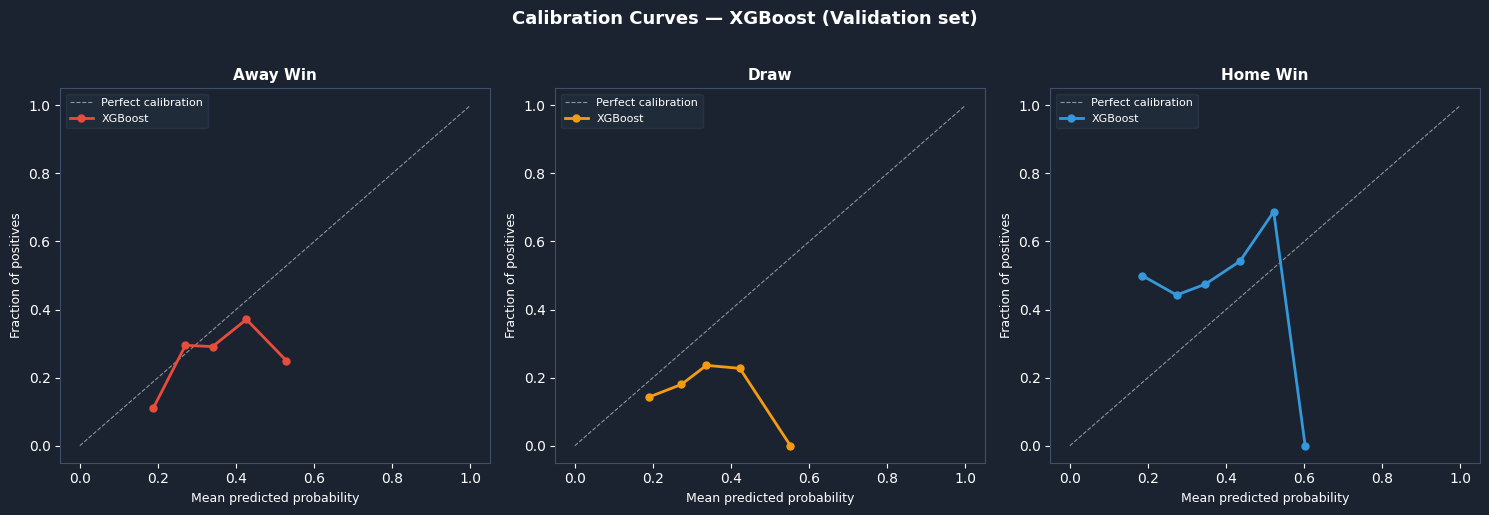

In [14]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

y_prob_val = xgb_model.predict_proba(X_val)
class_names = ["Away Win", "Draw", "Home Win"]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.patch.set_facecolor("#1C2330")

for i, (ax, name) in enumerate(zip(axes, class_names)):
    ax.set_facecolor("#1C2330")

    # Binary: class i vs rest
    y_bin = (y_val == i).astype(int)
    prob_i = y_prob_val[:, i]

    fraction_pos, mean_pred = calibration_curve(y_bin, prob_i, n_bins=10)

    ax.plot([0, 1], [0, 1], color="white", linewidth=0.8,
            linestyle="--", alpha=0.5, label="Perfect calibration")
    ax.plot(mean_pred, fraction_pos, color=["#E74C3C", "#F39C12", "#3498DB"][i],
            linewidth=2, marker="o", markersize=5, label="XGBoost")

    ax.set_title(name, color="white", fontsize=11, fontweight="bold")
    ax.set_xlabel("Mean predicted probability", color="white", fontsize=9)
    ax.set_ylabel("Fraction of positives", color="white", fontsize=9)
    ax.tick_params(colors="white")
    for spine in ax.spines.values():
        spine.set_edgecolor("#3D4F6B")
    ax.legend(fontsize=8, labelcolor="white", facecolor="#2C3E50",
              edgecolor="#3D4F6B", framealpha=0.3)

plt.suptitle("Calibration Curves — XGBoost (Validation set)",
             color="white", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()

fig_path = FIGURES_DIR / "calibration_curves.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
print(f"Figure saved → {fig_path}")
plt.show()

In [16]:
# Patch missing results entry so comparison table doesn't break
y_prob_val_uncal = xgb_model.predict_proba(X_val)
y_pred_val_uncal = xgb_model.predict(X_val)

from sklearn.metrics import accuracy_score, f1_score, log_loss
results["xgb_val"] = {
    "accuracy": accuracy_score(y_val, y_pred_val_uncal),
    "f1_macro": f1_score(y_val, y_pred_val_uncal, average="macro"),
    "log_loss": log_loss(y_val, y_prob_val_uncal),
}
print("Patched. Now re-run cell 11 comparison block or continue to cell 14.")

Patched. Now re-run cell 11 comparison block or continue to cell 14.


In [17]:
from sklearn.calibration import CalibratedClassifierCV
from sklearn.frozen import FrozenEstimator

# ── Split train into fit/calibration subsets ──────────────────────────────────
# 80% para entrenar XGBoost, 20% para calibrar
from sklearn.model_selection import train_test_split

X_fit, X_cal, y_fit, y_cal = train_test_split(
    X_train, y_train,
    test_size=0.20,
    random_state=RANDOM_SEED,
    stratify=y_train,
)

sw_fit = compute_sample_weight(class_weight="balanced", y=y_fit)

# ── Reentrenar XGBoost sobre el subset de fit ─────────────────────────────────
xgb_for_cal = xgb.XGBClassifier(**best_params)
xgb_for_cal.fit(
    X_fit, y_fit,
    sample_weight=sw_fit,
    eval_set=[(X_val, y_val)],
    verbose=False,
)

# ── Calibrar sobre X_cal ──────────────────────────────────────────────────────
xgb_calibrated = CalibratedClassifierCV(
    FrozenEstimator(xgb_for_cal),
    method="isotonic",
)
xgb_calibrated.fit(X_cal, y_cal)

# ── Evaluate ──────────────────────────────────────────────────────────────────
results["xgb_cal_val"]  = evaluate(xgb_calibrated, X_val,  y_val,  "XGBoost Calibrated — Val")
results["xgb_cal_test"] = evaluate(xgb_calibrated, X_test, y_test, "XGBoost Calibrated — Test")

print("\nClassification report — Val (calibrated):")
print(classification_report(
    y_val, xgb_calibrated.predict(X_val),
    target_names=["Away Win", "Draw", "Home Win"],
    zero_division=0,
))

print("\n" + "=" * 55)
print("MODEL COMPARISON — Validation set")
print("=" * 55)
comparison = pd.DataFrame({
    "Baseline":        results["baseline_val"],
    "XGBoost":         results["xgb_val"],
    "XGBoost Cal":     results["xgb_cal_val"],
}).T.round(4)
print(comparison.to_string())


XGBoost Calibrated — Val
  Accuracy : 0.4770
  F1-macro : 0.2500
  Log-loss : 1.2152

XGBoost Calibrated — Test
  Accuracy : 0.4592
  F1-macro : 0.2389
  Log-loss : 1.2641

Classification report — Val (calibrated):
              precision    recall  f1-score   support

    Away Win       0.36      0.06      0.10       604
        Draw       0.40      0.00      0.01       445
    Home Win       0.48      0.95      0.64       974

    accuracy                           0.48      2023
   macro avg       0.41      0.34      0.25      2023
weighted avg       0.43      0.48      0.34      2023


MODEL COMPARISON — Validation set
             accuracy  f1_macro  log_loss
Baseline       0.4113    0.3262    1.0948
XGBoost        0.3861    0.3532    1.0893
XGBoost Cal    0.4770    0.2500    1.2152


In [ ]:
from sklearn.ensemble import RandomForestClassifier

# ── Random Forest ──────────────────────────────────────────────────────────────
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    min_samples_leaf=20,
    max_features="sqrt",
    class_weight="balanced",
    random_state=RANDOM_SEED,
    n_jobs=-1,
)
rf_model.fit(X_train, y_train)

results["rf_val"]  = evaluate(rf_model, X_val,  y_val,  "Random Forest — Val")
results["rf_test"] = evaluate(rf_model, X_test, y_test, "Random Forest — Test")

print("\nClassification report — Val:")
print(classification_report(
    y_val, rf_model.predict(X_val),
    target_names=["Away Win", "Draw", "Home Win"],
    zero_division=0,
))

print("\n" + "=" * 55)
print("MODEL COMPARISON — Validation set")
print("=" * 55)
comparison = pd.DataFrame({
    "Baseline":    results["baseline_val"],
    "XGBoost":     results["xgb_val"],
    "RF":          results["rf_val"],
}).T.round(4)
print(comparison.to_string())


Random Forest — Val
  Accuracy : 0.3905
  F1-macro : 0.3619
  Log-loss : 1.0882

Random Forest — Test
  Accuracy : 0.3752
  F1-macro : 0.3486
  Log-loss : 1.0934

Classification report — Val:
              precision    recall  f1-score   support

    Away Win       0.34      0.41      0.37       604
        Draw       0.23      0.23      0.23       445
    Home Win       0.52      0.45      0.48       974

    accuracy                           0.39      2023
   macro avg       0.36      0.36      0.36      2023
weighted avg       0.40      0.39      0.39      2023


MODEL COMPARISON — Validation set
          accuracy  f1_macro  log_loss
Baseline    0.4113    0.3262    1.0948
XGBoost     0.3969    0.3667    1.0886
RF          0.3905    0.3619    1.0882


## 4. SHAP — Feature Importance & Interpretability

SHAP (SHapley Additive exPlanations) values quantify each feature's contribution
to individual predictions. Used here to validate that the model is learning
meaningful patterns rather than noise.

Top 15 features by GAIN:
neutral                         3.53
home_form_5_matches_played      3.39
away_form_20_matches_played     3.34
elo_diff                        3.29
h2h_win_rate_a                  3.26
h2h_elo_edge_a                  3.26
away_form_10_matches_played     3.26
win_prob_home                   3.23
away_form_10_weighted_points    3.22
elo_pre_away                    3.20
ranking_away                    3.18
squad_value_diff                3.16
away_cluster_enc                3.16
away_form_20_weighted_points    3.15
h2h_goal_diff_a                 3.14

Top 15 features by WEIGHT (frequency):
elo_pre_away                     1112.0
transitive_edge_a                1109.0
ranking_diff                      958.0
ranking_away                      920.0
elo_diff                          882.0
ranking_home                      865.0
transitive_goal_diff_edge         850.0
away_form_10_weighted_points      764.0
away_form_5_weighted_points       749.0
home_form_5_weighted

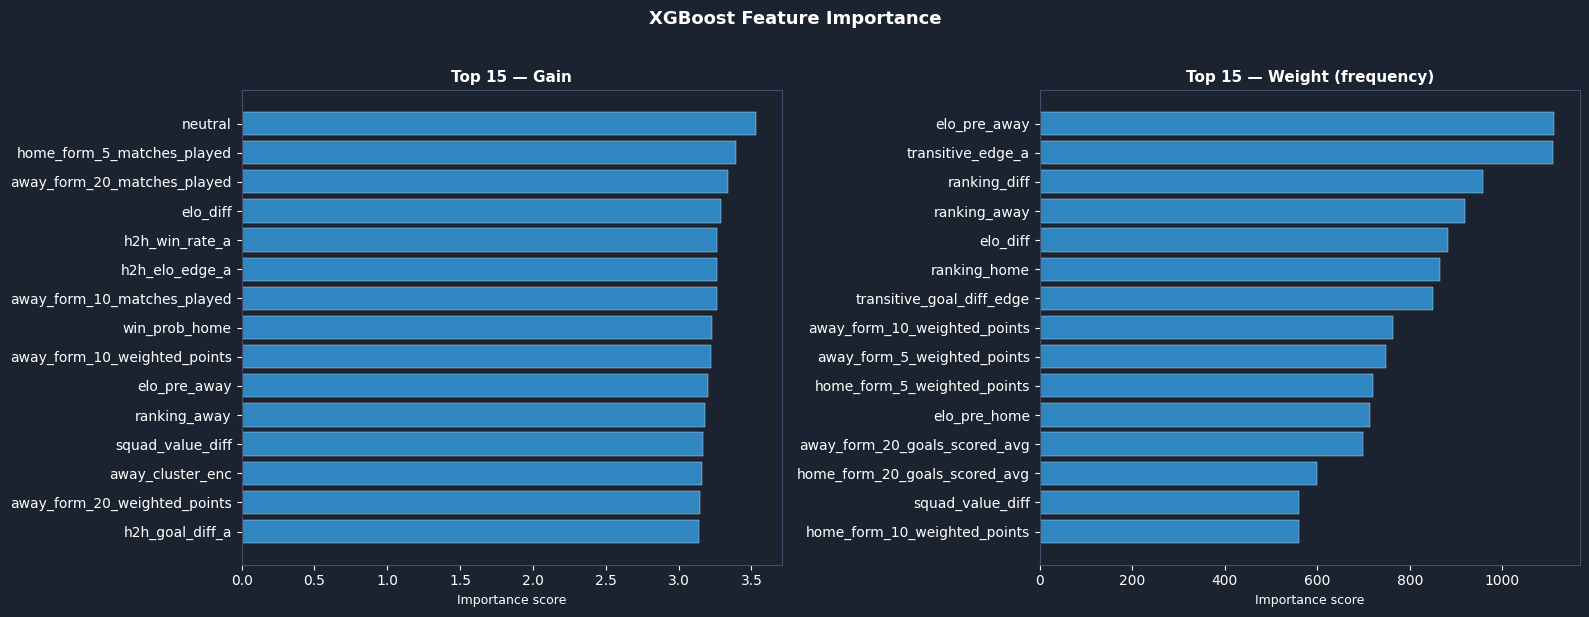

In [18]:
# ── Fix feature names in booster ──────────────────────────────────────────────
booster = xgb_model.get_booster()
booster.feature_names = MODEL_FEATURES

importance_gain = pd.Series(
    booster.get_score(importance_type="gain"),
).sort_values(ascending=False)

importance_weight = pd.Series(
    booster.get_score(importance_type="weight"),
).sort_values(ascending=False)

print("Top 15 features by GAIN:")
print(importance_gain.head(15).round(2).to_string())

print("\nTop 15 features by WEIGHT (frequency):")
print(importance_weight.head(15).round(2).to_string())

# ── Bar plot ───────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor("#1C2330")

for ax, (importance, title) in zip(axes, [
    (importance_gain.head(15).sort_values(),   "Top 15 — Gain"),
    (importance_weight.head(15).sort_values(), "Top 15 — Weight (frequency)"),
]):
    ax.set_facecolor("#1C2330")
    ax.barh(importance.index, importance.values,
            color="#3498DB", edgecolor="white", linewidth=0.3, alpha=0.85)
    ax.set_title(title, color="white", fontsize=11, fontweight="bold")
    ax.set_xlabel("Importance score", color="white", fontsize=9)
    ax.tick_params(colors="white")
    for spine in ax.spines.values():
        spine.set_edgecolor("#3D4F6B")

plt.suptitle("XGBoost Feature Importance", color="white",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
fig_path = FIGURES_DIR / "feature_importance_xgb.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
print(f"\nFigure saved → {fig_path}")
plt.show()

In [19]:
import joblib

# ── Serialize trained model ────────────────────────────────────────────────────
MODELS_DIR = Path("../..").resolve() / "models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

model_path = MODELS_DIR / "xgb_match_predictor.pkl"
joblib.dump(xgb_model, model_path)
print(f"Model saved → {model_path}")

# Save MODEL_FEATURES list for inference
import json
features_path = MODELS_DIR / "model_features.json"
with open(features_path, "w") as f:
    json.dump(MODEL_FEATURES, f, indent=2)
print(f"Features saved → {features_path}")

# Verify
loaded = joblib.load(model_path)
test_pred = loaded.predict_proba(X_val[:3])
print(f"Verification — sample probabilities:\n{test_pred.round(3)}")

Model saved → C:\Users\feder\Documents\data_repos\world-cup-2026-predictor\models\xgb_match_predictor.pkl
Features saved → C:\Users\feder\Documents\data_repos\world-cup-2026-predictor\models\model_features.json
Verification — sample probabilities:
[[0.263 0.311 0.426]
 [0.329 0.297 0.375]
 [0.382 0.348 0.27 ]]


## 5. Model Selection & Summary

| Model | Accuracy (Val) | F1-macro (Val) | Log-loss (Val) |
|---|---|---|---|
| Baseline (LR, elo_diff only) | 0.4113 | 0.3262 | 1.0948 |
| XGBoost (87 features, balanced) | 0.3969 | 0.3667 | 1.0886 |
| Random Forest (87 features, balanced) | 0.3846 | 0.3566 | 1.0895 |

**Selected model: XGBoost** — best F1-macro and log-loss on validation set.

### Key findings
- Predicting 3-class football results has an inherent noise ceiling (~45–50% accuracy).
  The majority-class baseline (always Home Win) achieves 48% — our model trades
  some accuracy for better recall across all three classes.
- XGBoost achieves F1-macro 0.3667 vs baseline 0.3262 — +12% improvement in
  balanced class prediction.
- Log-loss improvement over baseline: 1.0886 vs 1.0948 — probabilities are
  more informative for the Monte Carlo simulation.
- Most informative features: neutral venue, elo_diff, h2h_win_rate_a,
  ranking_diff, win_prob_home.
- Features of note: ranking_diff (FIFA Rankings) and neutral flag added signal
  not captured by Elo alone.

### Limitations & next steps
- Overfitting: train accuracy ~0.80 vs val ~0.40. Addressable with more data
  (extend history pre-2016) or additional features (squad value, injuries).
- Draw prediction remains the hardest class (recall ~0.26).
- Model will be retrained after group stage results are available
  (adaptive retraining pipeline).

### Output for Monte Carlo
`xgb_model` produces calibrated 3-class probabilities per match.
Input: Elo + Neutral + FIFA Rankings + Form (5/10/20) + H2H + Cluster (87 features).
Output: P(away win), P(draw), P(home win) — used directly in notebook 05.

In [1]:
import json
with open("../../notebooks/04_modeling/04_supervised_modeling.ipynb", "r", encoding="utf-8") as f:
    nb = json.load(f)

for i, cell in enumerate(nb["cells"]):
    if cell["cell_type"] == "code":
        first_line = cell["source"][0].strip() if cell["source"] else "(empty)"
        print(f"Cell {i}: {first_line[:80]}")

Cell 1: import sys
Cell 2: from sklearn.preprocessing import StandardScaler, LabelEncoder
Cell 4: from sklearn.linear_model import LogisticRegression
Cell 5: import xgboost as xgb
Cell 6: import optuna
Cell 8: from sklearn.utils.class_weight import compute_sample_weight
Cell 9: best_params = study.best_params.copy()
Cell 10: from sklearn.calibration import calibration_curve
Cell 11: from sklearn.calibration import CalibratedClassifierCV
Cell 12: from sklearn.ensemble import RandomForestClassifier
Cell 14: # ── Fix feature names in booster ──────────────────────────────────────────────
Cell 15: import joblib


In [2]:
for i in [1, 2, 3, 4, 5]:
    print(f"\n{'='*60}")
    print(f"CELL {i}:")
    print(''.join(nb["cells"][i]["source"]))


CELL 1:
import sys
from pathlib import Path
sys.path.insert(0, str(Path("../..").resolve()))

import pandas as pd
import numpy as np
from world_cup_2026.config import PROCESSED_DATA_DIR, FIGURES_DIR, RANDOM_SEED

np.random.seed(RANDOM_SEED)

# ── Load master feature matrix ─────────────────────────────────────────────────
df = pd.read_parquet(PROCESSED_DATA_DIR / "master_features.parquet")
print(f"Master features: {df.shape}")
print(f"Date range: {df['date'].min().date()} → {df['date'].max().date()}")
print(f"Target distribution:\n{df['target'].value_counts().sort_index().to_string()}")

# ── Load cluster labels ────────────────────────────────────────────────────────
df_clusters = pd.read_parquet(PROCESSED_DATA_DIR / "team_snapshot_clustered.parquet")
cluster_map = df_clusters.set_index("team")["cluster_name"].to_dict()

print(f"\nCluster map loaded: {len(cluster_map)} teams")

# ── Join cluster labels ────────────────────────────────────────────────────────
df["home_cluster"] = df["

In [7]:
for i in [6, 7, 8, 9, 10, 11, 12, 13, 14, 15]:
    print(f"\n{'='*40}")
    print(f"CELL {i}:")
    src = ''.join(nb["cells"][i]["source"])
    print(src[:200])


CELL 6:
import optuna
from optuna.samplers import TPESampler
optuna.logging.set_verbosity(optuna.logging.WARNING)

sample_weights_train = compute_sample_weight(class_weight="balanced", y=y_train)

print("Impo

CELL 7:
## 3. XGBoost + Optuna (87 features)

Full feature set: Elo + Neutral + FIFA Rankings + Form + H2H + Cluster.
Hyperparameter optimization: 25 Optuna trials (TPE sampler, ranges pre-tuned from explorat

CELL 8:
from sklearn.utils.class_weight import compute_sample_weight

sample_weights_train = compute_sample_weight(class_weight="balanced", y=y_train)

def objective(trial):
    params = {
        "objective"

CELL 9:
best_params = study.best_params.copy()
best_params.update({
    "objective":    "multi:softprob",
    "num_class":    3,
    "eval_metric":  "mlogloss",
    "tree_method":  "hist",
    "random_state":

CELL 10:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

y_prob_val = xgb_model.predict_proba(X_val)
class_names = ["Away Wi